# **Sentiment Analysis On Quora Duplicate Question Paris**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### **Data Overview**

In [2]:
df = pd.read_csv("train.csv")
df.shape

(404290, 6)

In [3]:
df.sample(10)

,id,qid1,qid2,question1,question2,is_duplicate
330105,330105,220432,50536,How do I integrate 3/ (e^x-2)?,How do I integrate [math]e^{x+2}[/math] and [m...,0
401808,401808,210102,535251,Which is better: Uber or Ola? Why?,What is better Uber or Ola? Why?,1
102891,102891,170164,170165,What is the difference between Clustering and ...,What is the difference between classification ...,1
365914,365914,4951,42108,Why do people ask questions on Quora that can ...,Why do people use Quora when they could easily...,1
367876,367876,498203,498204,Can I learn and get a job in Machine Learning ...,Andrew Ng: Can I get a job in machine learning...,0
280543,280543,396021,400135,How do I mark an already seen message as unseen?,"I sent a message in whatsapp. It says sent, no...",0
328630,328630,455197,455198,What are some brilliant features of Indian con...,What is the most outstanding feature of the In...,1
221768,221768,329193,329194,Why didn't Apple build its own search engine?,Why doesn't Apple have its own search engine?,1
144593,144593,228795,228796,What college should I attend?,Should I attend college?,0
66290,66290,114917,114918,What are the disadvantages of studying in a wo...,What are the advantages and disadvantages of a...,1


>- This dataset has two question pairs with the given label that is it a duplicate or not?

>- So, this is a Binary Classification Problem

In [4]:
# dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [5]:
# isnull values
print(df.isnull().sum())

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64


In [6]:
# any duplicate rows?
print("Duplicated Rows Count: ",df.duplicated().sum())

Duplicated Rows Count:  0


In [7]:
df.describe()

,id,qid1,qid2,is_duplicate
count,404290.000000,404290.000000,404290.000000,404290.000000
mean,202144.500000,217243.942418,220955.655337,0.369198
std,116708.614503,157751.700002,159903.182629,0.482588
min,0.000000,1.000000,2.000000,0.000000
25%,101072.250000,74437.500000,74727.000000,0.000000
50%,202144.500000,192182.000000,197052.000000,0.000000
75%,303216.750000,346573.500000,354692.500000,1.000000
max,404289.000000,537932.000000,537933.000000,1.000000


is_duplicate
0    255027
1    149263
Name: count, dtype: int64
Percentage Of Each Class:
is_duplicate
0    63.080215
1    36.919785
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

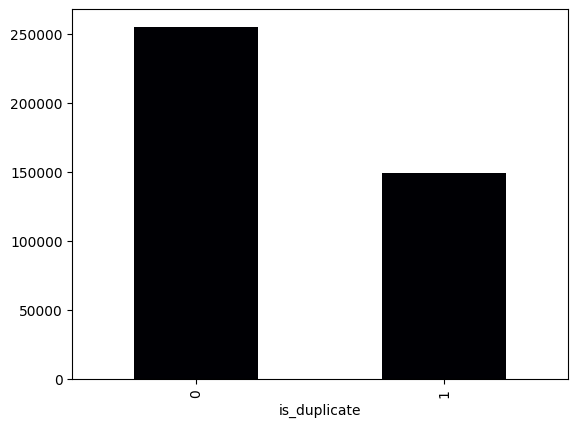

In [8]:
# number of duplicate and non-duplicate rows
print(df['is_duplicate'].value_counts())

print("Percentage Of Each Class:")
print(((df['is_duplicate'].value_counts())/(df['is_duplicate'].count()))*100)

df['is_duplicate'].value_counts().plot(kind = 'bar',colormap='magma')

> **Here the `is_duplicate` column is slightly Imbalanced**

In [9]:
# Repeated Questions
qid = pd.Series(df['qid1'].tolist() + df['qid2'].tolist())
print("Number of unique questions: ",np.unique(qid).shape[0])
x = qid.value_counts() > 1
print("Number of questions getting repeated: ",x[x].shape[0])

Number of unique questions:  537933
Number of questions getting repeated:  111780


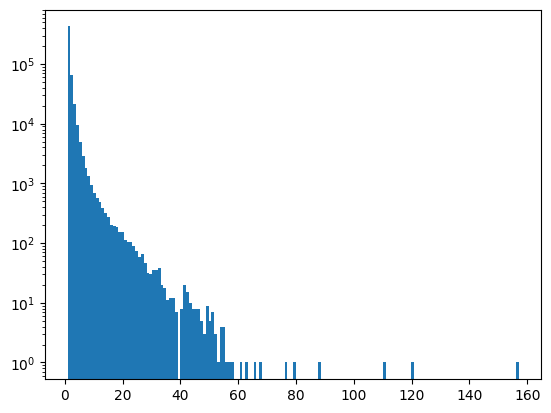

In [10]:
# Repeated Questions Histogram

plt.hist(qid.value_counts().values,bins = 160)
plt.yscale('log')
plt.show()

### **Removing the Null rows from the data**

In [11]:
df = df.dropna(subset = ['question1','question2'])

In [12]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [13]:
df.shape

(404287, 6)

In [14]:
new_df = df.sample(30000)
new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [15]:
new_df.duplicated().sum()

np.int64(0)

In [16]:
ques_df = new_df[['question1','question2']]
ques_df.head()

,question1,question2
274363,Are there any common trends among the administ...,Are there any common trends among the administ...
166610,How do I remember study points?,How can I remember studying points?
187128,When I say Croatia you think of?,"I'm visiting Croatia, Czech Republic, Slovenia..."
325015,Emoticons: What does “:/” mean?,What does the emoticon ^^ mean?
2807,What do Trump supporters think of his Cabinet ...,What do Trump supporters think about his recen...


In [17]:
from sklearn.feature_extraction.text import CountVectorizer

#merging the texts
questions = list(ques_df['question1']) + list(ques_df['question2'])
cv = CountVectorizer(max_features = 3000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(),2)

In [ ]:
temp_df1 = pd.DataFrame(q1_arr, index = ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index = ques_df.index)
temp_df = pd.concat([temp_df1,temp_df2],axis = 1)
temp_df.shape